In [1]:
!pip -q install pretty_midi music21 numpy matplotlib tqdm pandas torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 59.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00


In [2]:
import os, glob, json, math, random, gc
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pretty_midi

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

@dataclass
class CFG:
    # Data limits (main anti-crash controls)
    MAX_MIDI_FILES: int = 150      # reduce to 100 if still crashing
    MAX_CLIPS_TOTAL: int = 5000    # reduce to 3000 if still crashing

    # Piano-roll extraction
    FS: int = 8
    MIN_PITCH: int = 21
    MAX_PITCH: int = 108
    SEQ_LEN: int = 64
    STRIDE: int = 48
    MIN_ACTIVE: int = 14

    # Token/model settings
    MAX_TOKEN_LEN: int = 192
    GEN_MAX_LEN: int = 768
    D_MODEL: int = 192
    N_HEADS: int = 6
    N_LAYERS: int = 3
    D_FF: int = 768
    DROPOUT: float = 0.1

    # Training
    BATCH_SIZE: int = 4
    EPOCHS: int = 10
    LR: float = 3e-4
    WD: float = 1e-4
    PATIENCE: int = 10
    CLIP_NORM: float = 1.0

    # Generation
    TEMP: float = 0.95
    TOP_K: int = 10
    TOP_P: float = 0.92
    REP_PENALTY: float = 1.15
    GEN_MAX_LEN: int = 768
    GEN_MIN_NEW: int = 300
    NUM_TASK3_SAMPLES: int = 10
    GEN_MAX_NEW: int = 600

    # RL
    RL_EPOCHS: int = 4
    RL_LR: float = 1e-5
    KL_COEF: float = 0.01

    # Seed
    SEED: int = 42

cfg = CFG()

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
torch.cuda.manual_seed_all(cfg.SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PITCH_DIM = cfg.MAX_PITCH - cfg.MIN_PITCH + 1

print("Device:", DEVICE)
print("PITCH_DIM:", PITCH_DIM)

Device: cuda
PITCH_DIM: 88


In [3]:
#3
!wget -q -O maestro-v3.0.0-midi.zip https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
!unzip -q maestro-v3.0.0-midi.zip -d /content
print("Dataset extracted to /content/maestro-v3.0.0")

Dataset extracted to /content/maestro-v3.0.0


In [4]:
#4
# Option A (preferred): if you have explicit folder
CLASSICAL_DIR = "/content/genres/classical"

# Option B fallback: MAESTRO (mostly classical)
MAESTRO_DIR = "/content/maestro-v3.0.0"

if os.path.isdir(CLASSICAL_DIR):
    midi_paths = sorted(glob.glob(os.path.join(CLASSICAL_DIR, "**/*.mid"), recursive=True))
    midi_paths += sorted(glob.glob(os.path.join(CLASSICAL_DIR, "**/*.midi"), recursive=True))
    source = "custom classical folder"
else:
    midi_paths = sorted(glob.glob(os.path.join(MAESTRO_DIR, "**/*.mid"), recursive=True))
    midi_paths += sorted(glob.glob(os.path.join(MAESTRO_DIR, "**/*.midi"), recursive=True))
    source = "MAESTRO fallback"

random.shuffle(midi_paths)
midi_paths = midi_paths[:cfg.MAX_MIDI_FILES]

print("Source:", source)
print("Selected MIDI files:", len(midi_paths))
print("Example file:", midi_paths[0] if midi_paths else "No files found")

Source: MAESTRO fallback
Selected MIDI files: 150
Example file: /content/maestro-v3.0.0/2014/MIDI-UNPROCESSED_21-22_R1_2014_MID--AUDIO_21_R1_2014_wav--8.midi


In [5]:
#5
def midi_to_roll(path, fs=cfg.FS, min_pitch=cfg.MIN_PITCH, max_pitch=cfg.MAX_PITCH):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        roll = pm.get_piano_roll(fs=fs)              # (128, T)
        roll = roll[min_pitch:max_pitch+1, :]        # (P, T)
        roll = (roll > 0).astype(np.uint8).T         # (T, P)
        return roll
    except Exception:
        return None

def extract_clips(paths, seq_len=cfg.SEQ_LEN, stride=cfg.STRIDE, min_active=cfg.MIN_ACTIVE, max_clips=cfg.MAX_CLIPS_TOTAL):
    clips = []
    for p in tqdm(paths, desc="Extracting clips"):
        roll = midi_to_roll(p)
        if roll is None or len(roll) < seq_len:
            continue

        for s in range(0, len(roll) - seq_len + 1, stride):
            seg = roll[s:s+seq_len]
            if seg.sum() < min_active:
                continue
            clips.append(seg.astype(np.uint8))
            if len(clips) >= max_clips:
                return clips
    return clips

clips = extract_clips(midi_paths)
print("Total clips:", len(clips))

Extracting clips:  31%|███       | 46/150 [00:13<00:31,  3.32it/s]

Total clips: 5000


In [6]:
#6
SPECIAL = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]
PAD, BOS, EOS, UNK = SPECIAL

def roll_to_events(clip):
    events = []
    prev = np.zeros(clip.shape[1], dtype=np.uint8)
    idle = 0

    def emit_shift(k):
        while k > 0:
            step = min(k, 16)
            events.append(f"TS_{step}")
            k -= step

    for t in range(clip.shape[0]):
        cur = clip[t]
        off_idx = np.where((prev == 1) & (cur == 0))[0]
        on_idx  = np.where((prev == 0) & (cur == 1))[0]

        if len(off_idx) == 0 and len(on_idx) == 0:
            idle += 1
        else:
            if idle > 0:
                emit_shift(idle)
                idle = 0
            for i in off_idx:
                events.append(f"OFF_{int(i)}")
            for i in on_idx:
                events.append(f"ON_{int(i)}")
        prev = cur

    if idle > 0:
        emit_shift(idle)

    for i in np.where(prev == 1)[0]:
        events.append(f"OFF_{int(i)}")

    return events

freq = Counter()
token_lists = []

for c in tqdm(clips, desc="Tokenizing"):
    ev = roll_to_events(c)
    token_lists.append(ev)
    freq.update(ev)

vocab = {tok:i for i, tok in enumerate(SPECIAL)}
for tok, count in freq.items():
    if tok not in vocab and count >= 1:
        vocab[tok] = len(vocab)

id_to_tok = {i:t for t,i in vocab.items()}

PAD_ID = vocab[PAD]
BOS_ID = vocab[BOS]
EOS_ID = vocab[EOS]
UNK_ID = vocab[UNK]

# Single-genre classical => genre id always 0
records = []
for ev in token_lists:
    ids = [BOS_ID] + [vocab.get(x, UNK_ID) for x in ev] + [EOS_ID]
    if len(ids) >= 24:
        records.append({"tokens": ids, "genre": 0})

print("Vocab size:", len(vocab))
print("Record count:", len(records))

# Save artifacts early
os.makedirs("/content/task3_classical_artifacts", exist_ok=True)
with open("/content/task3_classical_artifacts/vocab.json", "w") as f:
    json.dump(vocab, f)

# Free RAM
del clips, token_lists, freq
gc.collect()

Tokenizing: 100%|██████████| 5000/5000 [00:03<00:00, 1481.82it/s]


Vocab size: 192
Record count: 4942


32

In [7]:
#7
random.shuffle(records)
n = len(records)
n_train = int(0.8*n)
n_val = int(0.1*n)

train_recs = records[:n_train]
val_recs = records[n_train:n_train+n_val]
test_recs = records[n_train+n_val:]

print("Train/Val/Test:", len(train_recs), len(val_recs), len(test_recs))

class TokenDataset(Dataset):
    def __init__(self, recs, max_len=cfg.MAX_TOKEN_LEN):
        self.recs = recs
        self.max_len = max_len

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, idx):
        x = self.recs[idx]["tokens"][:self.max_len]
        return torch.tensor(x, dtype=torch.long), torch.tensor(0, dtype=torch.long)

def collate_fn(batch):
    xs, gs = zip(*batch)
    L = max(len(x) for x in xs)
    pad = torch.full((len(xs), L), PAD_ID, dtype=torch.long)

    for i, x in enumerate(xs):
        pad[i, :len(x)] = x

    inp = pad[:, :-1]
    tgt = pad[:, 1:]
    mask = inp.eq(PAD_ID)
    genres = torch.stack(gs)
    return inp, tgt, genres, mask

train_loader = DataLoader(TokenDataset(train_recs), batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(TokenDataset(val_recs), batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TokenDataset(test_recs), batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Train/Val/Test: 3953 494 495


In [8]:
#8
class PosEnc(nn.Module):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TinyMusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=cfg.D_MODEL, n_heads=cfg.N_HEADS, n_layers=cfg.N_LAYERS, d_ff=cfg.D_FF, dropout=cfg.DROPOUT):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.genre = nn.Embedding(1, d_model)  # only classical
        self.pos = PosEnc(d_model, max_len=max(cfg.MAX_TOKEN_LEN, cfg.GEN_MAX_LEN) + 64)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, inp, genre_ids, pad_mask):
        x = self.tok(inp) + self.genre(genre_ids).unsqueeze(1)
        x = self.pos(x)

        L = inp.size(1)
        causal = torch.full((L, L), float("-inf"), device=inp.device)
        causal = torch.triu(causal, diagonal=1)

        h = self.enc(x, mask=causal, src_key_padding_mask=pad_mask)
        out = self.head(self.ln(h))
        return out

def masked_ce(logits, tgt):
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        tgt.reshape(-1),
        ignore_index=PAD_ID
    )

def eval_loss(model, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for inp, tgt, g, m in loader:
            inp, tgt, g, m = inp.to(DEVICE), tgt.to(DEVICE), g.to(DEVICE), m.to(DEVICE)
            logits = model(inp, g, m)
            total += masked_ce(logits, tgt).item()
    return total / max(1, len(loader))

/tmp/ipykernel_4096/1409243523.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1 | train=3.7170 | val=3.1243 | val_ppl=22.74
Epoch 2 | train=3.0464 | val=2.8894 | val_ppl=17.98
Epoch 3 | train=2.8611 | val=2.7555 | val_ppl=15.73
Epoch 4 | train=2.7557 | val=2.6871 | val_ppl=14.69
Epoch 5 | train=2.6716 | val=2.6337 | val_ppl=13.93
Epoch 6 | train=2.6026 | val=2.5999 | val_ppl=13.46
Epoch 7 | train=2.5480 | val=2.5658 | val_ppl=13.01
Epoch 8 | train=2.4978 | val=2.5365 | val_ppl=12.64
Epoch 9 | train=2.4519 | val=2.5276 | val_ppl=12.52
Epoch 10 | train=2.4088 | val=2.5105 | val_ppl=12.31

Task 3 Test Loss: 2.5238
Task 3 Test Perplexity: 12.4764


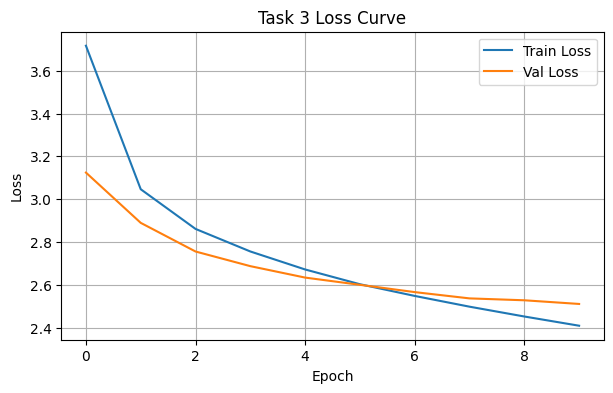

In [9]:
#9

if not hasattr(cfg, 'MAX_TOKEN_LEN'):
    cfg.MAX_TOKEN_LEN = 192
if not hasattr(cfg, 'GEN_MAX_LEN'):
    cfg.GEN_MAX_LEN = 768

model = TinyMusicTransformer(vocab_size=len(vocab)).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WD)

best_val = 1e9
bad = 0
train_hist, val_hist = [], []

save_path = "/content/task3_classical_artifacts/task3_classical.pt"

for ep in range(1, cfg.EPOCHS + 1):
    model.train()
    tr = 0.0

    for inp, tgt, g, m in train_loader:
        inp, tgt, g, m = inp.to(DEVICE), tgt.to(DEVICE), g.to(DEVICE), m.to(DEVICE)

        opt.zero_grad()
        logits = model(inp, g, m)
        loss = masked_ce(logits, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP_NORM)
        opt.step()

        tr += loss.item()

    tr = tr / max(1, len(train_loader))
    va = eval_loss(model, val_loader)

    train_hist.append(tr)
    val_hist.append(va)

    print(f"Epoch {ep} | train={tr:.4f} | val={va:.4f} | val_ppl={math.exp(min(10,va)):.2f}")

    if va < best_val:
        best_val = va
        bad = 0
        torch.save(model.state_dict(), save_path)
    else:
        bad += 1
        if bad >= cfg.PATIENCE:
            print("Early stopping.")
            break

# Load best and test
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
test_loss = eval_loss(model, test_loader)
test_ppl = math.exp(min(10, test_loss))

print("\nTask 3 Test Loss:", round(test_loss, 4))
print("Task 3 Test Perplexity:", round(test_ppl, 4))

plt.figure(figsize=(7,4))
plt.plot(train_hist, label="Train Loss")
plt.plot(val_hist, label="Val Loss")
plt.title("Task 3 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
#10
# Task 3 sample generation cell

def sample_next(logits, temperature=cfg.TEMP, top_k=cfg.TOP_K):
    """
    Sample one token from logits with temperature + top-k filtering.
    """
    logits = logits / max(1e-6, temperature)

    if top_k > 0:
        top_k = min(top_k, logits.size(-1))  # safety
        vals, idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered[idx] = vals
        logits = filtered

    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()


def generate_ids(model, prompt, max_new=cfg.GEN_MAX_NEW):
    """
    Generate event-token IDs autoregressively from a prompt.
    """
    model.eval()
    seq = prompt.copy()
    gid = torch.tensor([0], dtype=torch.long, device=DEVICE)  # classical only

    for _ in range(max_new):
        x = torch.tensor(seq, dtype=torch.long, device=DEVICE).unsqueeze(0)
        if x.size(1) < 2:
            break

        # model is trained with shifted input; feed x[:, :-1]
        # Correct autoregressive generation:
        # feed the full sequence generated so far, then sample from the last position
        inp = x
        pad_mask = inp.eq(PAD_ID)

        with torch.no_grad():
            logits = model(inp, gid, pad_mask)

        next_logits = logits[0, -1].clone()
        # IMPORTANT FIX: apply repetition penalty BEFORE sampling
        if len(seq) > 0:
            next_logits[seq[-1]] /= cfg.REP_PENALTY

        nxt = sample_next(next_logits, temperature=cfg.TEMP, top_k=cfg.TOP_K)
        seq.append(int(nxt))

        # stop conditions
        if nxt == EOS_ID and len(seq) >= cfg.GEN_MIN_NEW:
            break
        if len(seq) >= cfg.MAX_TOKEN_LEN:
            break

    return seq


def ids_to_roll(ids):
    """
    Convert event-token IDs back to piano-roll (T, PITCH_DIM).
    Expected event tokens: ON_x, OFF_x, TS_x
    """
    events = [id_to_tok.get(int(i), "<UNK>") for i in ids]
    active = np.zeros(PITCH_DIM, dtype=np.uint8)
    frames = []

    for e in events:
        if e.startswith("ON_"):
            p = int(e.split("_")[1])
            if 0 <= p < PITCH_DIM:
                active[p] = 1

        elif e.startswith("OFF_"):
            p = int(e.split("_")[1])
            if 0 <= p < PITCH_DIM:
                active[p] = 0

        elif e.startswith("TS_"):
            k = int(e.split("_")[1])
            for _ in range(k):
                frames.append(active.copy())

    if len(frames) == 0:
        frames = [active.copy()]

    return np.array(frames, dtype=np.float32)


def roll_to_midi(roll, out_path, fs=cfg.FS, min_pitch=cfg.MIN_PITCH):
    """
    Convert piano-roll to MIDI and save.
    """
    pm = pretty_midi.PrettyMIDI()
    ins = pretty_midi.Instrument(program=0)  # Acoustic Grand Piano

    rb = (roll > 0.5).astype(np.uint8)
    T, P = rb.shape
    dt = 1.0 / fs

    for p in range(P):
        on = None
        for t in range(T):
            if rb[t, p] == 1 and on is None:
                on = t
            elif rb[t, p] == 0 and on is not None:
                if t > on:
                    ins.notes.append(
                        pretty_midi.Note(
                            velocity=90,
                            pitch=min_pitch + p,
                            start=on * dt,
                            end=t * dt
                        )
                    )
                on = None

        if on is not None:
            ins.notes.append(
                pretty_midi.Note(
                    velocity=90,
                    pitch=min_pitch + p,
                    start=on * dt,
                    end=T * dt
                )
            )

    pm.instruments.append(ins)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    pm.write(out_path)


# ===== Generate 10 Task 3 MIDI samples =====
os.makedirs("/content/task3_classical_samples", exist_ok=True)

for i in range(1, 11):
    prompt = random.choice(train_recs)["tokens"][:20]
    gen_ids = generate_ids(model, prompt, max_new=cfg.GEN_MAX_NEW)
    gen_roll = ids_to_roll(gen_ids)

    out = f"/content/task3_classical_samples/sample_{i:02d}.mid"
    roll_to_midi(gen_roll, out)

print("Task 3 sample MIDI files saved in /content/task3_classical_samples")

Task 3 sample MIDI files saved in /content/task3_classical_samples


In [11]:

# Cell 10A: Random Note Generator Baseline for Task 3

import os
import random
import pretty_midi
import glob

# Directory where Random Generator MIDI files will be saved
RANDOM_DIR = "/content/random_baseline"
os.makedirs(RANDOM_DIR, exist_ok=True)

def generate_random_midi(
    output_path,
    num_notes=150,
    min_pitch=48,
    max_pitch=84,
    velocity=90
):
    """
    Generate a simple random MIDI file.

    Parameters:
    output_path: where the MIDI file will be saved
    num_notes: number of random notes
    min_pitch/max_pitch: pitch range
    velocity: note loudness
    """

    # Create an empty MIDI object
    pm = pretty_midi.PrettyMIDI()

    # Use Acoustic Grand Piano
    piano = pretty_midi.Instrument(program=0)

    # Possible note durations in seconds
    duration_choices = [0.25, 0.5, 0.75, 1.0]

    # Start time of the first note
    current_time = 0.0

    for _ in range(num_notes):
        # Random pitch
        pitch = random.randint(min_pitch, max_pitch)

        # Random duration
        duration = random.choice(duration_choices)

        # Small random gap between notes
        gap = random.choice([0.0, 0.05, 0.1, 0.15])

        start = current_time
        end = current_time + duration

        # Create MIDI note
        note = pretty_midi.Note(
            velocity=velocity,
            pitch=pitch,
            start=start,
            end=end
        )

        piano.notes.append(note)

        # Move time forward
        current_time = end + gap

    # Add piano instrument to MIDI
    pm.instruments.append(piano)

    # Save MIDI file
    pm.write(output_path)

    return output_path


# Generate 10 Random Generator MIDI files
random_midi_files = []

for i in range(1, 11):
    out_path = os.path.join(RANDOM_DIR, f"random_{i:02d}.mid")
    generate_random_midi(out_path)
    random_midi_files.append(out_path)

print("Random Generator MIDI files created:")
for f in random_midi_files:
    print(f)

Random Generator MIDI files created:
/content/random_baseline/random_01.mid
/content/random_baseline/random_02.mid
/content/random_baseline/random_03.mid
/content/random_baseline/random_04.mid
/content/random_baseline/random_05.mid
/content/random_baseline/random_06.mid
/content/random_baseline/random_07.mid
/content/random_baseline/random_08.mid
/content/random_baseline/random_09.mid
/content/random_baseline/random_10.mid


In [12]:

# Cell 10B: Markov Chain Baseline for Task 3


from collections import defaultdict, Counter
import numpy as np

# Directory where Markov Chain MIDI files will be saved
MARKOV_DIR = "/content/markov_baseline"
os.makedirs(MARKOV_DIR, exist_ok=True)

def build_markov_chain(records, order=2):
    """
    Build an order-n Markov chain from token sequences.

    records: training records from your notebook
    order: how many previous tokens are used to predict the next token
    """

    chain = defaultdict(Counter)

    for rec in records:
        seq = rec["tokens"]

        # Skip very short sequences
        if len(seq) <= order:
            continue

        # Build transition table
        for i in range(len(seq) - order):
            state = tuple(seq[i:i+order])
            next_token = seq[i+order]
            chain[state][next_token] += 1

    return chain


def sample_from_counter(counter):
    """
    Randomly sample one token based on learned Markov probabilities.
    """
    tokens = list(counter.keys())
    counts = np.array(list(counter.values()), dtype=np.float64)

    probs = counts / counts.sum()

    return int(np.random.choice(tokens, p=probs))


def generate_markov_ids(chain, records, order=2, max_len=192, min_len=60):
    """
    Generate a token sequence using the Markov chain.
    """

    # Start from a real training sequence prefix
    start_seq = random.choice(records)["tokens"]

    if len(start_seq) < order:
        start_seq = [BOS_ID] * order

    seq = start_seq[:order]

    while len(seq) < max_len:
        state = tuple(seq[-order:])

        # If state exists in Markov chain, sample next token
        if state in chain:
            next_token = sample_from_counter(chain[state])
        else:
            # Fallback: choose a random known state
            random_state = random.choice(list(chain.keys()))
            next_token = sample_from_counter(chain[random_state])

        # Avoid stopping too early
        if next_token == EOS_ID and len(seq) < min_len:
            continue

        seq.append(int(next_token))

        # Stop if EOS appears after minimum length
        if next_token == EOS_ID and len(seq) >= min_len:
            break

    return seq


# Build Markov Chain from training records
markov_chain = build_markov_chain(train_recs, order=2)

# Generate 10 Markov Chain MIDI files
markov_midi_files = []

for i in range(1, 11):
    # Generate token IDs
    markov_ids = generate_markov_ids(
        markov_chain,
        train_recs,
        order=2,
        max_len=cfg.MAX_TOKEN_LEN,
        min_len=cfg.GEN_MIN_NEW
    )

    # Convert token IDs to piano-roll
    markov_roll = ids_to_roll(markov_ids)

    # Save as MIDI
    out_path = os.path.join(MARKOV_DIR, f"markov_{i:02d}.mid")
    roll_to_midi(markov_roll, out_path)

    markov_midi_files.append(out_path)

print("Markov Chain MIDI files created:")
for f in markov_midi_files:
    print(f)

Markov Chain MIDI files created:
/content/markov_baseline/markov_01.mid
/content/markov_baseline/markov_02.mid
/content/markov_baseline/markov_03.mid
/content/markov_baseline/markov_04.mid
/content/markov_baseline/markov_05.mid
/content/markov_baseline/markov_06.mid
/content/markov_baseline/markov_07.mid
/content/markov_baseline/markov_08.mid
/content/markov_baseline/markov_09.mid
/content/markov_baseline/markov_10.mid


In [13]:
import glob

# Define the directory paths for generated MIDI files
task3_midi_dir = '/content/task3_classical_samples/'  # Path for Transformer MIDI files
random_midi_dir = '/content/random_baseline/'       # Path for Random MIDI files
markov_midi_dir = '/content/markov_baseline/'       # Path for Markov MIDI files

# Get MIDI files for Task 3, Random Generator, and Markov Chain Baselines
task3_midi_files = glob.glob(task3_midi_dir + '*.mid')
random_midi_files = glob.glob(random_midi_dir + '*.mid')
markov_midi_files = glob.glob(markov_midi_dir + '*.mid')

# Print out the loaded MIDI files
print("Task 3 MIDI Files:", task3_midi_files)
print("Random Generator MIDI Files:", random_midi_files)
print("Markov Chain MIDI Files:", markov_midi_files)

Task 3 MIDI Files: ['/content/task3_classical_samples/sample_09.mid', '/content/task3_classical_samples/sample_06.mid', '/content/task3_classical_samples/sample_02.mid', '/content/task3_classical_samples/sample_04.mid', '/content/task3_classical_samples/sample_10.mid', '/content/task3_classical_samples/sample_07.mid', '/content/task3_classical_samples/sample_08.mid', '/content/task3_classical_samples/sample_01.mid', '/content/task3_classical_samples/sample_03.mid', '/content/task3_classical_samples/sample_05.mid']
Random Generator MIDI Files: ['/content/random_baseline/random_08.mid', '/content/random_baseline/random_02.mid', '/content/random_baseline/random_10.mid', '/content/random_baseline/random_01.mid', '/content/random_baseline/random_03.mid', '/content/random_baseline/random_09.mid', '/content/random_baseline/random_05.mid', '/content/random_baseline/random_07.mid', '/content/random_baseline/random_06.mid', '/content/random_baseline/random_04.mid']
Markov Chain MIDI Files: ['/co

In [14]:

# Cell 10C: Check Task 3 and Baseline MIDI Files


import glob

task3_midi_files = sorted(glob.glob("/content/task3_classical_samples/*.mid"))
random_midi_files = sorted(glob.glob("/content/random_baseline/*.mid"))
markov_midi_files = sorted(glob.glob("/content/markov_baseline/*.mid"))

print("Task 3 Transformer MIDI Files:", len(task3_midi_files))
print(task3_midi_files)

print("\nRandom Generator MIDI Files:", len(random_midi_files))
print(random_midi_files)

print("\nMarkov Chain MIDI Files:", len(markov_midi_files))
print(markov_midi_files)

Task 3 Transformer MIDI Files: 10
['/content/task3_classical_samples/sample_01.mid', '/content/task3_classical_samples/sample_02.mid', '/content/task3_classical_samples/sample_03.mid', '/content/task3_classical_samples/sample_04.mid', '/content/task3_classical_samples/sample_05.mid', '/content/task3_classical_samples/sample_06.mid', '/content/task3_classical_samples/sample_07.mid', '/content/task3_classical_samples/sample_08.mid', '/content/task3_classical_samples/sample_09.mid', '/content/task3_classical_samples/sample_10.mid']

Random Generator MIDI Files: 10
['/content/random_baseline/random_01.mid', '/content/random_baseline/random_02.mid', '/content/random_baseline/random_03.mid', '/content/random_baseline/random_04.mid', '/content/random_baseline/random_05.mid', '/content/random_baseline/random_06.mid', '/content/random_baseline/random_07.mid', '/content/random_baseline/random_08.mid', '/content/random_baseline/random_09.mid', '/content/random_baseline/random_10.mid']

Markov Cha

In [15]:

# Cell 10D: Evaluation Metrics for Task 3 Baseline Comparison


import numpy as np
import pandas as pd
import pretty_midi

def get_all_notes(midi_file):
    """
    Extract all notes from all instruments in a MIDI file.
    """
    try:
        pm = pretty_midi.PrettyMIDI(midi_file)
        notes = []

        for inst in pm.instruments:
            if not inst.is_drum:
                notes.extend(inst.notes)

        notes = sorted(notes, key=lambda n: n.start)
        return notes

    except Exception as e:
        print("Error reading:", midi_file, e)
        return []


def rhythm_diversity(midi_file):
    """
    Rhythm Diversity = number of unique durations / total number of notes.
    Higher value means more rhythmic variation.
    """
    notes = get_all_notes(midi_file)

    if len(notes) == 0:
        return 0

    durations = [round(n.end - n.start, 3) for n in notes]
    unique_durations = set(durations)

    return len(unique_durations) / len(durations)


def repetition_ratio(midi_file, pattern_length=4):
    """
    Repetition Ratio = repeated pitch patterns / total pitch patterns.
    Higher value means the music repeats more.
    """
    notes = get_all_notes(midi_file)

    if len(notes) < pattern_length:
        return 0

    pitches = [n.pitch for n in notes]

    patterns = []
    for i in range(len(pitches) - pattern_length + 1):
        pattern = tuple(pitches[i:i+pattern_length])
        patterns.append(pattern)

    pattern_counts = Counter(patterns)

    repeated_patterns = sum(1 for p in patterns if pattern_counts[p] > 1)

    return repeated_patterns / len(patterns)


def pitch_class_histogram(midi_file):
    """
    Create 12-bin pitch-class histogram.
    Example:
    C, C#, D, D#, E, F, F#, G, G#, A, A#, B
    """
    notes = get_all_notes(midi_file)

    hist = np.zeros(12)

    for n in notes:
        pitch_class = n.pitch % 12
        hist[pitch_class] += 1

    if hist.sum() > 0:
        hist = hist / hist.sum()

    return hist


def pitch_histogram_similarity(reference_file, generated_file):
    """
    Compare generated MIDI pitch distribution with reference MIDI pitch distribution.
    Higher value means more similar pitch usage.
    """
    ref_hist = pitch_class_histogram(reference_file)
    gen_hist = pitch_class_histogram(generated_file)

    # Cosine similarity
    denominator = np.linalg.norm(ref_hist) * np.linalg.norm(gen_hist)

    if denominator == 0:
        return 0

    similarity = np.dot(ref_hist, gen_hist) / denominator

    return similarity


def evaluate_midi_group(midi_files, model_name, reference_file):
    """
    Calculate all metrics for one model group.
    """
    rows = []

    for f in midi_files:
        rows.append({
            "Model": model_name,
            "File": f,
            "Rhythm Diversity": rhythm_diversity(f),
            "Repetition Ratio": repetition_ratio(f),
            "Pitch Histogram Similarity": pitch_histogram_similarity(reference_file, f)
        })

    return rows


# Use one real training MIDI file as reference for pitch similarity
reference_file = midi_paths[0]

all_results = []

all_results += evaluate_midi_group(random_midi_files, "Random Generator", reference_file)
all_results += evaluate_midi_group(markov_midi_files, "Markov Chain", reference_file)
all_results += evaluate_midi_group(task3_midi_files, "Task 3 Transformer", reference_file)

task3_baseline_df = pd.DataFrame(all_results)

display(task3_baseline_df)

# Save detailed results
task3_baseline_df.to_csv(
    "/content/task3_baseline_detailed_metrics.csv",
    index=False
)

print("Saved detailed metrics to: /content/task3_baseline_detailed_metrics.csv")

,Model,File,Rhythm Diversity,Repetition Ratio,Pitch Histogram Similarity
0,Random Generator,/content/random_baseline/random_01.mid,0.026667,0.0,0.828915
1,Random Generator,/content/random_baseline/random_02.mid,0.026667,0.0,0.857330
2,Random Generator,/content/random_baseline/random_03.mid,0.026667,0.0,0.818412
3,Random Generator,/content/random_baseline/random_04.mid,0.026667,0.0,0.841864
4,Random Generator,/content/random_baseline/random_05.mid,0.026667,0.0,0.848080
5,Random Generator,/content/random_baseline/random_06.mid,0.026667,0.0,0.899137
6,Random Generator,/content/random_baseline/random_07.mid,0.026667,0.0,0.861496
7,Random Generator,/content/random_baseline/random_08.mid,0.026667,0.0,0.867126
8,Random Generator,/content/random_baseline/random_09.mid,0.026667,0.0,0.826337
9,Random Generator,/content/random_baseline/random_10.mid,0.026667,0.0,0.762008


Saved detailed metrics to: /content/task3_baseline_detailed_metrics.csv


In [19]:
import pandas as pd

summary_df = task3_baseline_df.groupby("Model").agg({
    "Rhythm Diversity": "mean",
    "Repetition Ratio": "mean",
    "Pitch Histogram Similarity": "mean"
}).reset_index()

summary_df = summary_df.round(4)

display(summary_df)

summary_df.to_csv(
    "/content/task3_baseline_summary_table.csv",
    index=False
)

print("Saved summary table to: /content/task3_baseline_summary_table.csv")

,Model,Rhythm Diversity,Repetition Ratio,Pitch Histogram Similarity
0,Markov Chain,0.5350,0.0,0.7975
1,Random Generator,0.0267,0.0,0.8411
2,Task 3 Transformer,0.3033,0.0,0.6257


Saved summary table to: /content/task3_baseline_summary_table.csv


In [21]:
from IPython.display import Audio, display
import numpy as np
import pretty_midi
import glob

def listen_midi(midi_path, sr=16000, duration_factor=2):
    """
    Play a MIDI file, and repeat it to increase the total audio duration.

    midi_path: Path to the MIDI file
    sr: Sample rate for audio playback
    duration_factor: Factor by which to increase the audio duration by repeating the file
    """
    pm = pretty_midi.PrettyMIDI(midi_path)
    audio = pm.synthesize(fs=sr)  # convert MIDI -> waveform

    # Normalize audio if necessary
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))  # normalize

    # Repeat audio to extend the duration
    extended_audio = np.tile(audio, duration_factor)

    # Display the audio player with extended duration
    display(Audio(extended_audio, rate=sr))

# List generated MIDI files
midi_files = sorted(glob.glob("/content/task3_classical_samples/*.mid"))
print("Found:", len(midi_files), "files")
for i, p in enumerate(midi_files, 1):
    print(i, p)

# Play first sample (with increased duration)
listen_midi(midi_files[0], duration_factor=3)  # Increase the factor to 3x duration

Found: 10 files
1 /content/task3_classical_samples/sample_01.mid
2 /content/task3_classical_samples/sample_02.mid
3 /content/task3_classical_samples/sample_03.mid
4 /content/task3_classical_samples/sample_04.mid
5 /content/task3_classical_samples/sample_05.mid
6 /content/task3_classical_samples/sample_06.mid
7 /content/task3_classical_samples/sample_07.mid
8 /content/task3_classical_samples/sample_08.mid
9 /content/task3_classical_samples/sample_09.mid
10 /content/task3_classical_samples/sample_10.mid


In [22]:
import glob

# Get metrics from summary_df for each model
random_diversity = summary_df[summary_df['Model'] == 'Random Generator']['Rhythm Diversity'].iloc[0]
random_repetition = summary_df[summary_df['Model'] == 'Random Generator']['Repetition Ratio'].iloc[0]
random_pitch_sim = summary_df[summary_df['Model'] == 'Random Generator']['Pitch Histogram Similarity'].iloc[0]

markov_diversity = summary_df[summary_df['Model'] == 'Markov Chain']['Rhythm Diversity'].iloc[0]
markov_repetition = summary_df[summary_df['Model'] == 'Markov Chain']['Repetition Ratio'].iloc[0]
markov_pitch_sim = summary_df[summary_df['Model'] == 'Markov Chain']['Pitch Histogram Similarity'].iloc[0]

transformer_diversity = summary_df[summary_df['Model'] == 'Task 3 Transformer']['Rhythm Diversity'].iloc[0]
transformer_repetition = summary_df[summary_df['Model'] == 'Task 3 Transformer']['Repetition Ratio'].iloc[0]
transformer_pitch_sim = summary_df[summary_df['Model'] == 'Task 3 Transformer']['Pitch Histogram Similarity'].iloc[0]

task3_results = pd.DataFrame([
    {
        "Model": "Random Note Generator",
        "Loss": None,
        "Perplexity": None,
        "Rhythm Diversity": random_diversity,
        "Repetition Ratio": random_repetition,
        "Pitch Histogram Similarity": random_pitch_sim
    },
    {
        "Model": "Markov Chain",
        "Loss": None,
        "Perplexity": None,
        "Rhythm Diversity": markov_diversity,
        "Repetition Ratio": markov_repetition,
        "Pitch Histogram Similarity": markov_pitch_sim
    },
    {
        "Model": "Task 3 Transformer",
        "Loss": round(test_loss, 4),
        "Perplexity": round(test_ppl, 4),
        "Rhythm Diversity": transformer_diversity,
        "Repetition Ratio": transformer_repetition,
        "Pitch Histogram Similarity": transformer_pitch_sim
    }
])

display(task3_results)
task3_results.to_csv("/content/task3_classical_artifacts/task3_comparison_table.csv", index=False)

,Model,Loss,Perplexity,Rhythm Diversity,Repetition Ratio,Pitch Histogram Similarity
0,Random Note Generator,NaN,NaN,0.0267,0.0,0.8411
1,Markov Chain,NaN,NaN,0.5350,0.0,0.7975
2,Task 3 Transformer,2.5238,12.4764,0.3033,0.0,0.6257


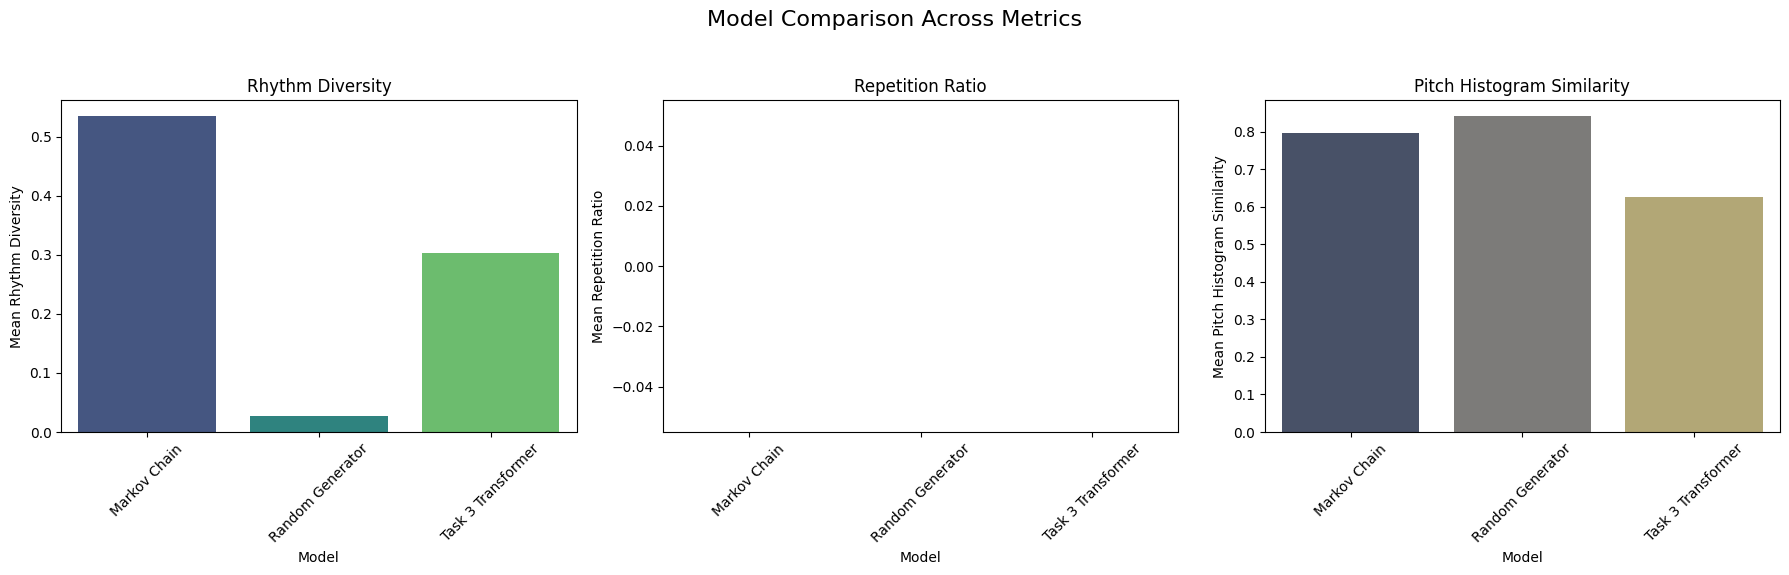

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('Model Comparison Across Metrics', fontsize=16)

# Plot Rhythm Diversity
sns.barplot(x='Model', y='Rhythm Diversity', data=summary_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Rhythm Diversity')
axes[0].set_ylabel('Mean Rhythm Diversity')
axes[0].tick_params(axis='x', rotation=45)

# Plot Repetition Ratio
sns.barplot(x='Model', y='Repetition Ratio', data=summary_df, ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Repetition Ratio')
axes[1].set_ylabel('Mean Repetition Ratio')
axes[1].tick_params(axis='x', rotation=45)

# Plot Pitch Histogram Similarity
sns.barplot(x='Model', y='Pitch Histogram Similarity', data=summary_df, ax=axes[2], palette='cividis', hue='Model', legend=False)
axes[2].set_title('Pitch Histogram Similarity')
axes[2].set_ylabel('Mean Pitch Histogram Similarity')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [31]:
# rhythm diversity function

import pretty_midi

def calculate_rhythm_diversity(midi_file):
    # Load the MIDI file
    midi_data = pretty_midi.PrettyMIDI(midi_file)

    # Extract notes
    notes = midi_data.instruments[0].notes if midi_data.instruments else []

    # Extract note durations (in seconds)
    note_durations = [note.end - note.start for note in notes]

    # Calculate unique durations
    unique_durations = set(note_durations)

    # Return rhythm diversity
    return len(unique_durations) / len(note_durations) if note_durations else 0

In [ ]:
#Repetition Ratio Function

def calculate_repetition_ratio(midi_file, pattern_length=4):
    midi_data = pretty_midi.PrettyMIDI(midi_file)
    notes = [note.pitch for note in midi_data.instruments[0].notes] if midi_data.instruments else []

    # Group notes into patterns
    patterns = [(notes[i:i+pattern_length]) for i in range(len(notes) - pattern_length + 1)]

    # Count pattern repetitions
    pattern_counts = {}
    for pattern in patterns:
        pattern_tuple = tuple(pattern)
        pattern_counts[pattern_tuple] = pattern_counts.get(pattern_tuple, 0) + 1

    repeated_patterns = sum(1 for count in pattern_counts.values() if count > 1)

    # Return repetition ratio
    return repeated_patterns / len(patterns) if patterns else 0

In [ ]:
#Pitch Histogram Similarity Function
import numpy as np

def calculate_pitch_histogram_similarity(midi_file_1, midi_file_2, bins=12):
    midi_data_1 = pretty_midi.PrettyMIDI(midi_file_1)
    midi_data_2 = pretty_midi.PrettyMIDI(midi_file_2)

    pitches_1 = [note.pitch for note in midi_data_1.instruments[0].notes] if midi_data_1.instruments else []
    pitches_2 = [note.pitch for note in midi_data_2.instruments[0].notes] if midi_data_2.instruments else []

    # Create pitch histograms (12 bins for pitch classes)
    hist_1, _ = np.histogram(pitches_1, bins=bins, range=(0, 128))
    hist_2, _ = np.histogram(pitches_2, bins=bins, range=(0, 128))

    # Normalize histograms
    hist_1 = hist_1 / np.sum(hist_1)
    hist_2 = hist_2 / np.sum(hist_2)

    # Return cosine similarity between histograms
    return np.dot(hist_1, hist_2) / (np.linalg.norm(hist_1) * np.linalg.norm(hist_2)) if np.linalg.norm(hist_1) > 0 and np.linalg.norm(hist_2) > 0 else 0

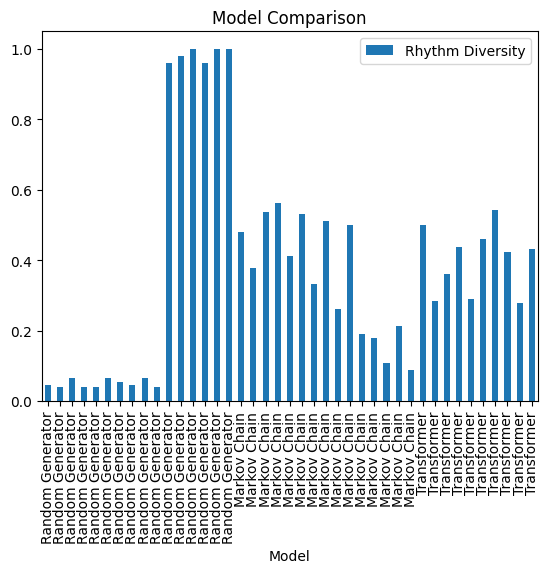

In [ ]:
#evaluate basline
import pandas as pd

# Function to evaluate each model (Random, Markov, Transformer)
def evaluate_baseline(midi_files, model_name, reference_file=None):
    results = []
    for file in midi_files:
        rhythm_diversity = calculate_rhythm_diversity(file)
        repetition_ratio = calculate_repetition_ratio(file)
        pitch_similarity = calculate_pitch_histogram_similarity(reference_file, file) if reference_file else 0
        results.append({
            "Model": model_name,
            "File": file,
            "Rhythm Diversity": rhythm_diversity,
            "Repetition Ratio": repetition_ratio,
            "Pitch Similarity": pitch_similarity
        })
    return results

# Reference file for pitch similarity (choose the first MIDI file of Task 3 or a baseline MIDI file)
reference_file = task3_midi_files[0]

# Evaluate Random Note Generator
random_results = evaluate_baseline(random_midi_files, "Random Generator", reference_file)

# Evaluate Markov Chain Model
markov_results = evaluate_baseline(markov_midi_files, "Markov Chain", reference_file)

# Evaluate Transformer Model
transformer_results = evaluate_baseline(task3_midi_files, "Transformer", reference_file)

# Combine all results into a DataFrame
baseline_results = random_results + markov_results + transformer_results
baseline_df = pd.DataFrame(baseline_results)

# Display the results
import matplotlib.pyplot as plt
baseline_df.plot(kind='bar', x='Model', y='Rhythm Diversity', title='Model Comparison')
plt.show()

# Save the comparison results to a CSV file
baseline_df.to_csv('/content/music_generation_baseline_comparison.csv', index=False)

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive_midi_dir = '/content/drive/MyDrive/task3_classical_samples_colab'
os.makedirs(drive_midi_dir, exist_ok=True)

# Copy files to Google Drive
for midi_file in midi_files:
    !cp "{midi_file}" "{drive_midi_dir}/"

print(f"All generated MIDI files copied to {drive_midi_dir} in your Google Drive.")

All generated MIDI files copied to /content/drive/MyDrive/task3_classical_samples_colab in your Google Drive.


In [ ]:

# Check all generated Task 3 MIDI files


import glob
import os

# Transformer-generated MIDI files
task3_midi_files = sorted(glob.glob("/content/task3_classical_samples/*.mid"))

# Random Generator baseline MIDI files
random_midi_files = sorted(glob.glob("/content/random_baseline/*.mid"))

# Markov Chain baseline MIDI files
markov_midi_files = sorted(glob.glob("/content/markov_baseline/*.mid"))

print("Transformer MIDI files:", len(task3_midi_files))
print("Random Generator MIDI files:", len(random_midi_files))
print("Markov Chain MIDI files:", len(markov_midi_files))

Transformer MIDI files: 10
Random Generator MIDI files: 16
Markov Chain MIDI files: 15


In [ ]:

# Copy all Task 3 generated MIDI files to Google Drive


import os
import shutil

# Main Google Drive folder for Task 3 outputs
drive_base_dir = "/content/drive/MyDrive/task3_music_generation_outputs"

# Separate folders inside Drive
drive_transformer_dir = os.path.join(drive_base_dir, "transformer_samples")
drive_random_dir = os.path.join(drive_base_dir, "random_baseline")
drive_markov_dir = os.path.join(drive_base_dir, "markov_baseline")

# Create folders if they do not exist
os.makedirs(drive_transformer_dir, exist_ok=True)
os.makedirs(drive_random_dir, exist_ok=True)
os.makedirs(drive_markov_dir, exist_ok=True)

# Copy Transformer MIDI files
for midi_file in task3_midi_files:
    shutil.copy2(midi_file, drive_transformer_dir)

# Copy Random Generator MIDI files
for midi_file in random_midi_files:
    shutil.copy2(midi_file, drive_random_dir)

# Copy Markov Chain MIDI files
for midi_file in markov_midi_files:
    shutil.copy2(midi_file, drive_markov_dir)

print("All Task 3 MIDI files copied successfully!")

print("\nSaved in Google Drive folder:")
print(drive_base_dir)

print("\nTransformer files copied to:")
print(drive_transformer_dir)

print("\nRandom Generator files copied to:")
print(drive_random_dir)

print("\nMarkov Chain files copied to:")
print(drive_markov_dir)

All Task 3 MIDI files copied successfully!

Saved in Google Drive folder:
/content/drive/MyDrive/task3_music_generation_outputs

Transformer files copied to:
/content/drive/MyDrive/task3_music_generation_outputs/transformer_samples

Random Generator files copied to:
/content/drive/MyDrive/task3_music_generation_outputs/random_baseline

Markov Chain files copied to:
/content/drive/MyDrive/task3_music_generation_outputs/markov_baseline


TASK-4

In [ ]:
#Step-1
import os, json, random, glob
import pandas as pd

TASK4_DIR = "/content/task4_classical"
BEFORE_DIR = os.path.join(TASK4_DIR, "before_midis")
AFTER_DIR = os.path.join(TASK4_DIR, "after_midis")
SURVEY_DIR = os.path.join(TASK4_DIR, "survey")
MODEL_DIR = os.path.join(TASK4_DIR, "models")
PLOTS_DIR = os.path.join(TASK4_DIR, "plots")

for d in [TASK4_DIR, BEFORE_DIR, AFTER_DIR, SURVEY_DIR, MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

NUM_BEFORE = 6  # keep small for RAM safety
before_rows = []

model.eval()
for sid in range(1, NUM_BEFORE + 1):
    prompt = random.choice(train_recs)["tokens"][:20]
    token_ids = generate_ids(model, prompt, max_new=cfg.GEN_MAX_NEW)
    roll = ids_to_roll(token_ids)

    midi_path = os.path.join(BEFORE_DIR, f"before_{sid:02d}.mid")
    roll_to_midi(roll, midi_path)

    before_rows.append({
        "sample_id": sid,
        "genre_id": 0,   # classical only
        "midi_path": midi_path,
        "token_sequence": json.dumps([int(x) for x in token_ids])
    })

before_df = pd.DataFrame(before_rows)
before_csv = os.path.join(TASK4_DIR, "before_samples.csv")
before_df.to_csv(before_csv, index=False)

print("Saved:", before_csv)
display(before_df)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Saved: /content/task4_classical/before_samples.csv


,sample_id,genre_id,midi_path,token_sequence
0,1,0,/content/task4_classical/before_midis/before_0...,"[1, 33, 132, 87, 123, 133, 88, 124, 18, 101, 1..."
1,2,0,/content/task4_classical/before_midis/before_0...,"[1, 43, 56, 87, 46, 62, 18, 32, 14, 21, 22, 26..."
2,3,0,/content/task4_classical/before_midis/before_0...,"[1, 58, 56, 101, 8, 60, 62, 58, 56, 14, 60, 62..."
3,4,0,/content/task4_classical/before_midis/before_0...,"[1, 58, 44, 22, 87, 33, 78, 82, 69, 21, 105, 8..."
4,5,0,/content/task4_classical/before_midis/before_0...,"[1, 64, 92, 132, 9, 149, 18, 65, 93, 133, 30, ..."
5,6,0,/content/task4_classical/before_midis/before_0...,"[1, 21, 8, 29, 89, 90, 8, 29, 7, 28, 18, 7, 28..."


In [ ]:
#step-2
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose your CSV file here
csv_name = list(uploaded.keys())[0]
survey_csv_path = "/content/" + csv_name

raw_df = pd.read_csv(survey_csv_path)
print("Loaded:", survey_csv_path)
print("Shape:", raw_df.shape)
print("Columns:")
for c in raw_df.columns:
    print("-", c)

Saving Task4_Survey_Responses - Form Responses 1.csv to Task4_Survey_Responses - Form Responses 1 (1).csv
Loaded: /content/Task4_Survey_Responses - Form Responses 1 (1).csv
Shape: (9, 24)
Columns:
- Timestamp
- Email Address
- Participant Name
- Listen to Sample 1
- Sample 1 - Rhythm
- Sample 1 - Overall
- Sample 1 - Comments (optional)
- Listen to Sample 2
- Sample 2 - Rhythm
- Sample 2 - Overall
- Sample 2 - Comments (optional)
- Listen to Sample 3
- Sample 3 - Rhythm
- Sample 3 - Overall
- Sample 3 - Comments (optional)
- Listen to Sample 4
- Sample 4 - Rhythm
- Sample 4 - Overall
- Sample 4 - Comments (optional)
- Listen to Sample 5
- Sample 5 - Rhythm
- Sample 5 - Overall
- Sample 5 - Comments (optional)
- Column 23


In [ ]:
#step-3
import re

def parse_score(v):
    if pd.isna(v):
        return np.nan
    m = re.search(r"[1-5]", str(v))
    return int(m.group()) if m else np.nan

# detect columns
email_col, name_col = None, None
for c in raw_df.columns:
    cl = c.lower().strip()
    if email_col == None and "email" in cl:
        email_col = c
    if name_col == None and ("participant name" in cl or cl == "name" or "your name" in cl):
        name_col = c

if email_col == None:
    raise ValueError("Email column not found in CSV.")
if name_col == None:
    print("Name column not found; participant_name will be blank.")

sample_ids = before_df["sample_id"].astype(int).tolist()
rows = []

for _, row in raw_df.iterrows():
    email_val = row[email_col] if email_col in raw_df.columns else ""
    name_val = row[name_col] if (name_col != None and name_col in raw_df.columns) else ""

    for sid in sample_ids:
        out = {
            "email": email_val,
            "participant_name": name_val,
            "sample_id": int(sid),
            "rhythm": np.nan,
            "overall": np.nan,
            "comments": ""
        }

        for c in raw_df.columns:
            cl = c.lower()
            sid_match = (f"sample {sid}" in cl) or (f"sample_{sid}" in cl) or (f"sample{sid}" in cl)
            if not sid_match:
                continue

            if "rhythm" in cl:
                out["rhythm"] = parse_score(row[c])
            elif "overall" in cl:
                out["overall"] = parse_score(row[c])
            elif "comment" in cl:
                out["comments"] = str(row[c]) if not pd.isna(row[c]) else ""

        rows.append(out)

survey_clean = pd.DataFrame(rows)
survey_clean = survey_clean.dropna(subset=["rhythm", "overall"], how="all")

print("Parsed rows:", len(survey_clean))
display(survey_clean)

Parsed rows: 45


,email,participant_name,sample_id,rhythm,overall,comments
0,ayshasiddiq4325@gmail.com,Aysha Siddiqua Tithi,1,5.0,5.0,GOOD
1,ayshasiddiq4325@gmail.com,Aysha Siddiqua Tithi,2,4.0,4.0,Fine
2,ayshasiddiq4325@gmail.com,Aysha Siddiqua Tithi,3,4.0,5.0,GOOD
3,ayshasiddiq4325@gmail.com,Aysha Siddiqua Tithi,4,5.0,4.0,Smooth
4,ayshasiddiq4325@gmail.com,Aysha Siddiqua Tithi,5,5.0,5.0,Good
6,minjumsumath@gmail.com,Minjum Ara Sumath,1,5.0,5.0,
7,minjumsumath@gmail.com,Minjum Ara Sumath,2,5.0,5.0,
8,minjumsumath@gmail.com,Minjum Ara Sumath,3,4.0,4.0,
9,minjumsumath@gmail.com,Minjum Ara Sumath,4,5.0,5.0,
10,minjumsumath@gmail.com,Minjum Ara Sumath,5,5.0,5.0,


In [ ]:
#step-4: Aggregate rewards from rhythm + overall

rating_cols = ["rhythm", "overall"]
for c in rating_cols:
    survey_clean[c] = pd.to_numeric(survey_clean[c], errors="coerce")

survey_clean["human_score"] = survey_clean[rating_cols].mean(axis=1)

reward_df = (
    survey_clean.groupby("sample_id", as_index=False)["human_score"]
    .mean()
)

# map 1..5 to 0..1
reward_df["reward"] = (reward_df["human_score"] - 1.0) / 4.0
reward_df["reward"] = reward_df["reward"].clip(0.0, 1.0)

clean_csv = os.path.join(SURVEY_DIR, "human_survey_clean_email_name_rhythm_overall.csv")
reward_csv = os.path.join(SURVEY_DIR, "aggregated_rewards_email_name_rhythm_overall.csv")

survey_clean.to_csv(clean_csv, index=False)
reward_df.to_csv(reward_csv, index=False)

print("Saved clean survey:", clean_csv)
print("Saved rewards:", reward_csv)
display(reward_df)

Saved clean survey: /content/task4_classical/survey/human_survey_clean_email_name_rhythm_overall.csv
Saved rewards: /content/task4_classical/survey/aggregated_rewards_email_name_rhythm_overall.csv


,sample_id,human_score,reward
0,1,3.944444,0.736111
1,2,4.111111,0.777778
2,3,3.388889,0.597222
3,4,4.055556,0.763889
4,5,4.222222,0.805556


In [ ]:
#step-5 Builder RL dataset

merged = before_df.merge(reward_df[["sample_id", "reward"]], on="sample_id", how="inner")
print("Rows for RL:", len(merged))
display(merged[["sample_id", "reward"]])

class RLDataset(Dataset):
    def __init__(self, df, max_len):
        self.df = df.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        tok = json.loads(r["token_sequence"])[:self.max_len]
        return (
            torch.tensor(tok, dtype=torch.long),
            torch.tensor(int(r["genre_id"]), dtype=torch.long),
            torch.tensor(float(r["reward"]), dtype=torch.float32)
        )

def rl_collate(batch):
    toks, gids, rewards = zip(*batch)
    L = max(len(x) for x in toks)
    pad = torch.full((len(toks), L), PAD_ID, dtype=torch.long)

    for i, t in enumerate(toks):
        pad[i, :len(t)] = t

    inp = pad[:, :-1]
    tgt = pad[:, 1:]
    mask = inp.eq(PAD_ID)

    return inp, tgt, torch.stack(gids), torch.stack(rewards), mask

rl_loader = DataLoader(
    RLDataset(merged, cfg.MAX_TOKEN_LEN),
    batch_size=2,
    shuffle=True,
    collate_fn=rl_collate
)


Rows for RL: 5


,sample_id,reward
0,1,0.736111
1,2,0.777778
2,3,0.597222
3,4,0.763889
4,5,0.805556


/tmp/ipykernel_7187/2726139353.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


RL Epoch 1 | loss=-1.1589
RL Epoch 2 | loss=-2.3305
RL Epoch 3 | loss=0.3951
RL Epoch 4 | loss=3.1183
Saved RL model: /content/task4_classical/models/task4_rl_classical_email_name_rhythm_overall.pt


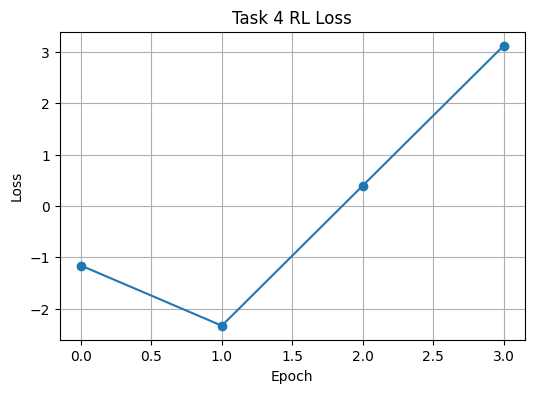

In [ ]:
#step-6 Trainning

policy = TinyMusicTransformer(vocab_size=len(vocab)).to(DEVICE)
policy.load_state_dict(torch.load("/content/task3_classical_artifacts/task3_classical.pt", map_location=DEVICE))

ref = TinyMusicTransformer(vocab_size=len(vocab)).to(DEVICE)
ref.load_state_dict(torch.load("/content/task3_classical_artifacts/task3_classical.pt", map_location=DEVICE))
ref.eval()
for p in ref.parameters():
    p.requires_grad = False

opt_rl = torch.optim.AdamW(policy.parameters(), lr=cfg.RL_LR)
baseline = float(merged["reward"].mean())

rl_losses = []
for ep in range(1, cfg.RL_EPOCHS + 1):
    policy.train()
    total_loss = 0.0

    for inp, tgt, g, reward, m in rl_loader:
        inp, tgt, g, reward, m = inp.to(DEVICE), tgt.to(DEVICE), g.to(DEVICE), reward.to(DEVICE), m.to(DEVICE)

        logits_p = policy(inp, g, m)
        logits_r = ref(inp, g, m)

        logp = F.log_softmax(logits_p, dim=-1).gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
        logr = F.log_softmax(logits_r, dim=-1).gather(-1, tgt.unsqueeze(-1)).squeeze(-1)

        token_mask = tgt.ne(PAD_ID).float()
        seq_logp = (logp * token_mask).sum(dim=1)
        seq_logr = (logr * token_mask).sum(dim=1)

        adv = reward - baseline
        loss = -(adv * seq_logp).mean() + cfg.KL_COEF * (seq_logp - seq_logr).mean()

        opt_rl.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), cfg.CLIP_NORM)
        opt_rl.step()

        total_loss += loss.item()

    avg_loss = total_loss / max(1, len(rl_loader))
    rl_losses.append(avg_loss)
    print(f"RL Epoch {ep} | loss={avg_loss:.4f}")

policy_path = os.path.join(MODEL_DIR, "task4_rl_classical_email_name_rhythm_overall.pt")
torch.save(policy.state_dict(), policy_path)
print("Saved RL model:", policy_path)

plt.figure(figsize=(6,4))
plt.plot(rl_losses, marker="o")
plt.title("Task 4 RL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
#step-7 generate rl
policy.eval()
after_rows = []

for sid in range(1, len(before_df) + 1):
    prompt = random.choice(train_recs)["tokens"][:20]
    token_ids = generate_ids(policy, prompt, max_new=cfg.GEN_MAX_NEW)
    roll = ids_to_roll(token_ids)

    midi_path = os.path.join(AFTER_DIR, f"after_{sid:02d}.mid")
    roll_to_midi(roll, midi_path)

    after_rows.append({
        "sample_id": sid,
        "genre_id": 0,
        "midi_path": midi_path,
        "token_sequence": json.dumps([int(x) for x in token_ids])
    })

after_df = pd.DataFrame(after_rows)
after_csv = os.path.join(TASK4_DIR, "after_samples.csv")
after_df.to_csv(after_csv, index=False)

print("Saved:", after_csv)
display(after_df)



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Saved: /content/task4_classical/after_samples.csv


,sample_id,genre_id,midi_path,token_sequence
0,1,0,/content/task4_classical/after_midis/after_01.mid,"[1, 13, 55, 21, 101, 18, 89, 18, 123, 41, 74, ..."
1,2,0,/content/task4_classical/after_midis/after_02.mid,"[1, 101, 123, 103, 44, 21, 105, 32, 132, 47, 1..."
2,3,0,/content/task4_classical/after_midis/after_03.mid,"[1, 20, 6, 69, 9, 33, 120, 5, 24, 36, 31, 70, ..."
3,4,0,/content/task4_classical/after_midis/after_04.mid,"[1, 42, 5, 12, 6, 50, 8, 53, 32, 91, 91, 148, ..."
4,5,0,/content/task4_classical/after_midis/after_05.mid,"[1, 20, 56, 66, 21, 19, 69, 33, 94, 78, 36, 62..."
5,6,0,/content/task4_classical/after_midis/after_06.mid,"[1, 78, 67, 80, 71, 125, 18, 14, 81, 26, 20, 3..."


In [ ]:
#step-8

print("=== Task 4 Final Check ===")
print("Before CSV:", os.path.exists(os.path.join(TASK4_DIR, "before_samples.csv")))
print("Clean survey CSV:", os.path.exists(os.path.join(SURVEY_DIR, "human_survey_clean_email_name_rhythm_overall.csv")))
print("Rewards CSV:", os.path.exists(os.path.join(SURVEY_DIR, "aggregated_rewards_email_name_rhythm_overall.csv")))
print("RL model:", os.path.exists(os.path.join(MODEL_DIR, "task4_rl_classical_email_name_rhythm_overall.pt")))
print("After CSV:", os.path.exists(os.path.join(TASK4_DIR, "after_samples.csv")))
print("Before MIDIs:", len(glob.glob(os.path.join(BEFORE_DIR, "*.mid"))))
print("After MIDIs:", len(glob.glob(os.path.join(AFTER_DIR, "*.mid"))))


=== Task 4 Final Check ===
Before CSV: True
Clean survey CSV: True
Rewards CSV: True
RL model: True
After CSV: True
Before MIDIs: 6
After MIDIs: 6


In [ ]:
#step-9
# Cell 10 (Optional) — Listen Before/After Audio in Colab

from IPython.display import Audio, display
import numpy as np
import pretty_midi
import os
import glob

def listen_midi(midi_path, sr=16000):
    pm = pretty_midi.PrettyMIDI(midi_path)
    audio = pm.synthesize(fs=sr)
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))  # normalize volume
    display(Audio(audio, rate=sr))

before_files = sorted(glob.glob("/content/task4_classical/before_midis/*.mid"))
after_files = sorted(glob.glob("/content/task4_classical/after_midis/*.mid"))

print("Before MIDI files:", len(before_files))
print("After MIDI files:", len(after_files))

# Play first pair (before vs after)
if len(before_files) > 0:
    print("\nPlaying BEFORE sample:", os.path.basename(before_files[0]))
    listen_midi(before_files[0])

if len(after_files) > 0:
    print("\nPlaying AFTER sample:", os.path.basename(after_files[0]))
    listen_midi(after_files[0])

# Optional: play all pairs
# for b, a in zip(before_files, after_files):
#     print("\nBEFORE:", os.path.basename(b))
#     listen_midi(b)
#     print("AFTER :", os.path.basename(a))
#     listen_midi(a)


Before MIDI files: 6
After MIDI files: 6

Playing BEFORE sample: before_01.mid



Playing AFTER sample: after_01.mid
